### Ustawienie ziarna

In [1]:
import os
os.environ['PYTHONHASHSEED'] = str(42)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

### Biblioteki

In [ ]:
from src.data.create_dataset import create_final_dataset
import pandas as pd
import torch
import torch.nn as nn

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, classification_report
from src.data.set_seed import set_seed
set_seed(42)

from xgboost import XGBClassifier
from matplotlib import pyplot as plt

from src.data.data_loader import train_test_split_data, create_dataloader
from src.models.classifier import BinaryClassifier
from src.models.classifier_emb import BinaryClassifierEmbeddings
from src.models.naive_classifier import NaiveClassifier
from src.models.train_model import train_classifier, evaluate_model
from src.visualization.visualize import plot_confusion_matrix
from src.features.feature_importance import permutation_importance_dataloader_advanced
from src.features.clean_column_names import clean_column_names
from src.data.create_ohe_dataset import create_ohe_dataset
from src.data.create_embedding_dataset import create_embeddings_dataset, get_categorical_and_numerical_columns, get_embedding_sizes

/home/psik/GITHUB/IUM/IUM-long-stay-insights/src/data/utils.py:13: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


PYTHONHASHSEED       → 42
CUBLAS_WORKSPACE_CONFIG → :4096:8
python.random_seed   → 2147483648
numpy.random_seed    → 42
torch.cpu_seed       → 42
torch.cuda_seed      → 42


### Załadowanie danych

In [3]:
final_df = create_final_dataset()
final_df.head()

,id,host_is_superhost,host_verifications,host_acceptance_rate,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,...,total_english_reviews,count_negative_english,count_positive_english,amenities,standardized_amenities,num_of_amenities,num_of_other_amenities,has_wifi,has_air_conditioning,num_of_top_10_common_amenities
0,27262,t,"['email', 'phone']",100.0,ΑΜΠΕΛΟΚΗΠΟΙ,37.98924,23.76500,Entire rental unit,Entire home/apt,2,...,17.0,0.0,17.0,"[""Heating - split type ductless system"", ""Dish...","['OTHER', 'OTHER', 'OTHER', 'OTHER', 'Refriger...",37,25,True,False,9
1,809874,f,"['email', 'phone']",96.0,ΚΟΥΚΑΚΙ-ΜΑΚΡΥΓΙΑΝΝΗ,37.96215,23.72179,Entire rental unit,Entire home/apt,4,...,82.0,0.0,82.0,"[""Host greets you"", ""Dishes and silverware"", ""...","['OTHER', 'OTHER', 'Washer', 'TV', 'OTHER', 'R...",21,12,True,True,7
2,866381,t,"['email', 'phone', 'work_email']",97.0,ΝΕΟΣ ΚΟΣΜΟΣ,37.95523,23.72443,Entire condo,Entire home/apt,3,...,31.0,0.0,31.0,"[""Coffee"", ""Dishes and silverware"", ""Washer"", ...","['Coffee maker', 'OTHER', 'Washer', 'Condition...",49,29,True,True,12
3,886724,f,['email'],0.0,ΚΥΨΕΛΗ,37.99745,23.73973,Entire rental unit,Entire home/apt,2,...,17.0,1.0,16.0,"[""Host greets you"", ""Luggage dropoff allowed"",...","['OTHER', 'OTHER', 'Washer', 'OTHER', 'OTHER',...",20,13,True,True,6
4,896212,t,"['email', 'phone']",100.0,ΜΟΥΣΕΙΟ-ΕΞΑΡΧΕΙΑ-ΝΕΑΠΟΛΗ,37.98844,23.73845,Entire rental unit,Entire home/apt,2,...,423.0,3.0,420.0,"[""Host greets you"", ""Coffee"", ""Dishes and silv...","['OTHER', 'Coffee maker', 'OTHER', 'OTHER', 'O...",45,31,True,True,9


In [24]:
final_df_numerical_columns = final_df.select_dtypes(include=[np.number, np.bool]).columns.tolist()
final_df_categorical_columns = final_df.select_dtypes(exclude=[np.number, np.bool]).columns.tolist()

print("Numerical columns: ", final_df_numerical_columns)
print("Categorical columns: ", final_df_categorical_columns)

Numerical columns:  ['id', 'host_acceptance_rate', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'reviews_per_month', 'availability_eoy', 'number_of_reviews_ly', 'total_bookings', 'total_reviews', 'total_english_reviews', 'count_negative_english', 'count_positive_english', 'num_of_amenities', 'num_of_other_amenities', 'has_wifi', 'has_air_conditioning', 'num_of_top_10_common_amenities']
Categorical columns:  ['host_is_superhost', 'host_verifications', 'neighbourhood_cleansed', 'property_type', 'room_type', 'bathrooms_text', 'license', 'instant_bookable', 'target', 'amenities', 'standardized_amenities']


# Klasyfikatory

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Naiwny

In [26]:
numerical_df = final_df[final_df_numerical_columns + ['target']].copy()
numerical_df = numerical_df.fillna(0)
numerical_df = numerical_df.drop(columns=['id'])
numerical_df.head(5)

,host_acceptance_rate,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,review_scores_rating,review_scores_accuracy,...,total_reviews,total_english_reviews,count_negative_english,count_positive_english,num_of_amenities,num_of_other_amenities,has_wifi,has_air_conditioning,num_of_top_10_common_amenities,target
0,100.0,37.98924,23.76500,2,1.0,1.0,1.0,131.0,4.86,4.89,...,29.0,17.0,0.0,17.0,37,25,True,False,9,short
1,96.0,37.96215,23.72179,4,1.0,1.0,2.0,108.0,4.96,4.97,...,97.0,82.0,0.0,82.0,21,12,True,True,7,short
2,97.0,37.95523,23.72443,3,1.0,1.0,1.0,85.0,4.95,4.98,...,40.0,31.0,0.0,31.0,49,29,True,True,12,long
3,0.0,37.99745,23.73973,2,1.0,1.0,1.0,56.0,4.61,4.88,...,18.0,17.0,1.0,16.0,20,13,True,True,6,short
4,100.0,37.98844,23.73845,2,1.0,1.0,1.0,63.0,4.95,4.94,...,515.0,423.0,3.0,420.0,45,31,True,True,9,long


In [27]:
x_train, x_test, y_train, y_test = train_test_split_data(df=numerical_df, test_size=0.2, target_column='target')

# adding validation set
x_train_final, x_val, y_train_final, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

train_dataloader = create_dataloader(x_train_final, y_train_final, batch_size=32)
val_dataloader = create_dataloader(x_val, y_val, batch_size=32)
test_dataloader = create_dataloader(x_test, y_test, batch_size=32)

In [28]:
naive_classifier = NaiveClassifier(input_size=len(x_train.columns), output=0).to(device)

In [29]:
all_preds, all_labels = evaluate_model(naive_classifier, test_dataloader)

Evaluating: 100%|██████████| 181/181 [00:00<00:00, 300.23it/s]

Accuracy: 0.7805
ROC AUC: 0.5000
Average Precision: 0.2195


In [30]:
y_pred = np.argmax(all_preds, axis=1)

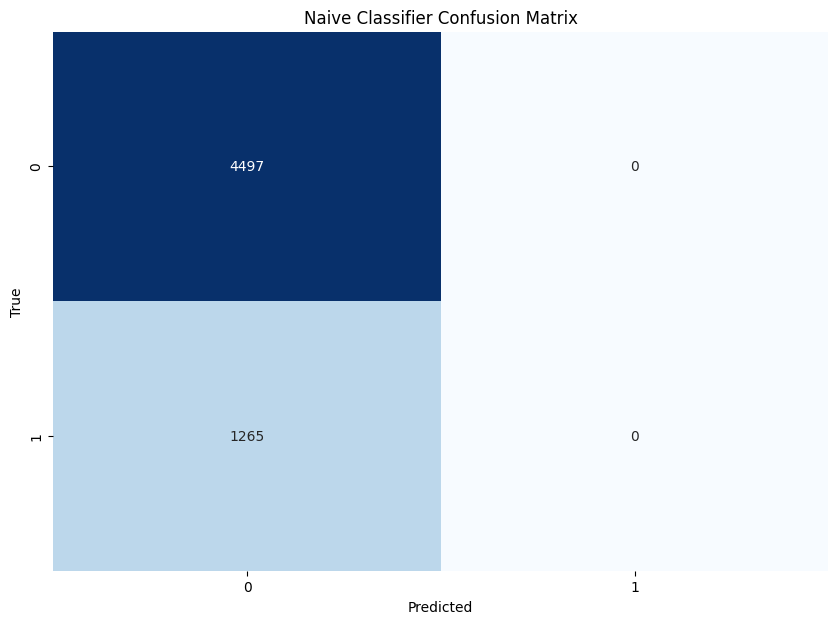

In [31]:
plot_confusion_matrix(all_labels, y_pred, title='Naive Classifier Confusion Matrix')

In [32]:
torch.save(naive_classifier.state_dict(), "../models/NaiveClassifier.pth")

## 2.Dane tylko numeryczne

In [33]:
classifier_v1 = BinaryClassifier(input_size=len(x_train.columns), output_size=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(classifier_v1.parameters(), lr=0.001)

In [34]:
train_classifier(
    model=classifier_v1,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=50,
    device=device
)

Epoch [1/50] | Train Loss: 0.3622 | Val Loss: 0.4158 | Val Acc: 0.8251


Epoch [2/50] | Train Loss: 0.2910 | Val Loss: 0.2810 | Val Acc: 0.8644


Epoch [3/50] | Train Loss: 0.2672 | Val Loss: 0.2587 | Val Acc: 0.8698


Epoch [4/50] | Train Loss: 0.2588 | Val Loss: 0.2712 | Val Acc: 0.8598


Epoch [5/50] | Train Loss: 0.2523 | Val Loss: 0.2600 | Val Acc: 0.8642


...

Epoch [46/50] | Train Loss: 0.2056 | Val Loss: 0.2209 | Val Acc: 0.8893


Epoch [47/50] | Train Loss: 0.2036 | Val Loss: 0.2296 | Val Acc: 0.8791


Epoch [48/50] | Train Loss: 0.2039 | Val Loss: 0.2343 | Val Acc: 0.8833


Epoch [49/50] | Train Loss: 0.2024 | Val Loss: 0.2243 | Val Acc: 0.8833


Epoch [50/50] | Train Loss: 0.2034 | Val Loss: 0.2205 | Val Acc: 0.8876
Training complete!


Evaluating: 100%|██████████| 181/181 [00:00<00:00, 225.77it/s]


Accuracy: 0.8896
ROC AUC: 0.9502
Average Precision: 0.8117


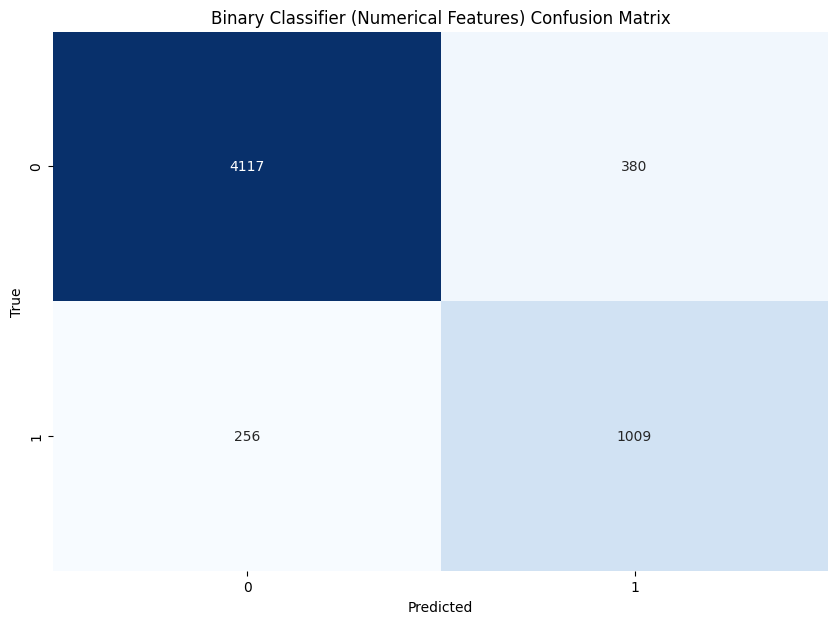

In [35]:
all_preds, all_labels = evaluate_model(classifier_v1, test_dataloader)
y_pred = np.argmax(all_preds, axis=1)
plot_confusion_matrix(all_labels, y_pred, title='Binary Classifier (Numerical Features) Confusion Matrix')

## 3. Dane One Hot Encoding

In [34]:
DROP_COLUMNS = ['id', 'mean_embedding', 'listing_id_x', 'listing_id_y', 'amenities', 'standardized_amenities', 'neighbourhood_cleansed', 'license']
POST_COLUMNS = ['availability_eoy', 'number_of_reviews_ly']

ohe_df = create_ohe_dataset(
    df=final_df,
    drop_cols=DROP_COLUMNS,
    drop_post_ohe=POST_COLUMNS,
    target_col='target',
    fillna_value=0
)
ohe_df.head()

,host_acceptance_rate,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,review_scores_rating,review_scores_accuracy,...,bathrooms_text_7 shared baths,bathrooms_text_8 baths,bathrooms_text_8 shared baths,bathrooms_text_8.5 baths,bathrooms_text_9 baths,bathrooms_text_Half-bath,bathrooms_text_Private half-bath,bathrooms_text_Shared half-bath,instant_bookable_f,instant_bookable_t
0,100.0,37.98924,23.76500,2,1.0,1.0,1.0,131.0,4.86,4.89,...,False,False,False,False,False,False,False,False,False,True
1,96.0,37.96215,23.72179,4,1.0,1.0,2.0,108.0,4.96,4.97,...,False,False,False,False,False,False,False,False,True,False
2,97.0,37.95523,23.72443,3,1.0,1.0,1.0,85.0,4.95,4.98,...,False,False,False,False,False,False,False,False,True,False
3,0.0,37.99745,23.73973,2,1.0,1.0,1.0,56.0,4.61,4.88,...,False,False,False,False,False,False,False,False,True,False
4,100.0,37.98844,23.73845,2,1.0,1.0,1.0,63.0,4.95,4.94,...,False,False,False,False,False,False,False,False,False,True


In [37]:
x_train, x_test, y_train, y_test = train_test_split_data(df=ohe_df, test_size=0.2, target_column='target')

# adding validation set
x_train_final, x_val, y_train_final, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

train_dataloader = create_dataloader(x_train_final, y_train_final, batch_size=32)
val_dataloader = create_dataloader(x_val, y_val, batch_size=32)
test_dataloader = create_dataloader(x_test, y_test, batch_size=32)

In [38]:
classifier_v2 = BinaryClassifier(input_size=len(x_train_final.columns), output_size=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(classifier_v2.parameters(), lr=0.001)

# assertions to check data integrity
assert not x_train.isnull().any().any(), "NaNs found in x_train"
assert not np.isinf(x_train.to_numpy()).any(), "Infs found in x_train"
assert set(y_train.unique()).issubset({0, 1}), "Invalid labels in y_train"

In [39]:
train_classifier(
    model=classifier_v2,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=50,
    device=device
)

Epoch [1/50] | Train Loss: 0.3069 | Val Loss: 0.2609 | Val Acc: 0.8700


Epoch [2/50] | Train Loss: 0.2099 | Val Loss: 0.1872 | Val Acc: 0.9102


Epoch [3/50] | Train Loss: 0.1899 | Val Loss: 0.1920 | Val Acc: 0.9110


Epoch [4/50] | Train Loss: 0.1777 | Val Loss: 0.1880 | Val Acc: 0.9108


Epoch [5/50] | Train Loss: 0.1706 | Val Loss: 0.2090 | Val Acc: 0.9054


...

Epoch [46/50] | Train Loss: 0.1191 | Val Loss: 0.1934 | Val Acc: 0.9301


Epoch [47/50] | Train Loss: 0.1228 | Val Loss: 0.1399 | Val Acc: 0.9347


Epoch [48/50] | Train Loss: 0.1165 | Val Loss: 0.1641 | Val Acc: 0.9273


Epoch [49/50] | Train Loss: 0.1144 | Val Loss: 0.1581 | Val Acc: 0.9304


Epoch [50/50] | Train Loss: 0.1199 | Val Loss: 0.1432 | Val Acc: 0.9340
Training complete!


Evaluating: 100%|██████████| 181/181 [00:00<00:00, 206.18it/s]


Accuracy: 0.9386
ROC AUC: 0.9826
Average Precision: 0.9445


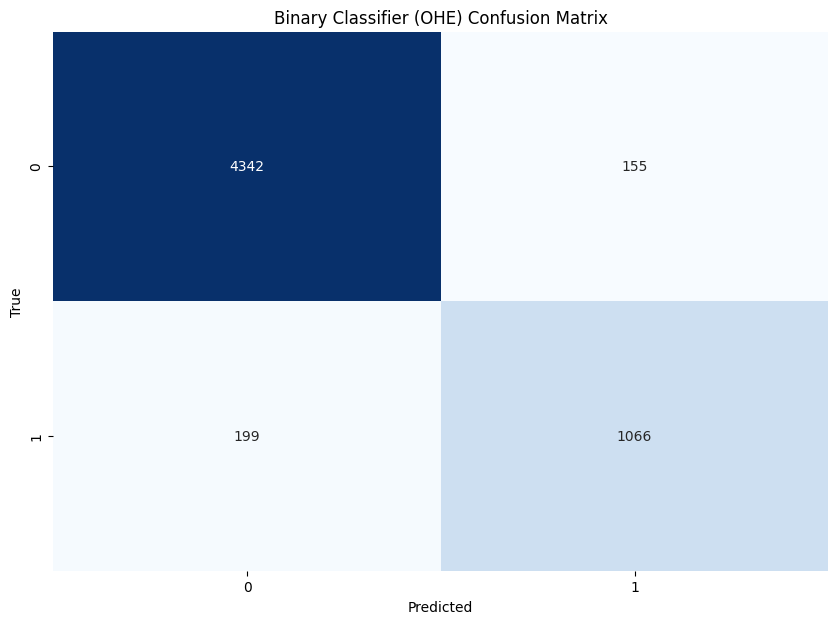

In [40]:
all_preds, all_labels = evaluate_model(classifier_v2, test_dataloader, device)
y_pred = np.argmax(all_preds, axis=1)
plot_confusion_matrix(all_labels, y_pred, title='Binary Classifier (OHE) Confusion Matrix')

In [41]:
torch.save(classifier_v2.state_dict(), "../models/OHE_CLASSIFIER.pth")

## 4. Embeddingi

In [19]:
set_seed(42)

PYTHONHASHSEED       → 42
CUBLAS_WORKSPACE_CONFIG → :4096:8
python.random_seed   → 2147483648
numpy.random_seed    → 42
torch.cpu_seed       → 42
torch.cuda_seed      → 42


In [20]:
embeddings_df = create_embeddings_dataset(df=final_df)

emb_categorical_columns, emb_numerical_columns = get_categorical_and_numerical_columns(embeddings_df)

print("Categorical columns: ", emb_categorical_columns)
print("Numerical columns: ", emb_numerical_columns)

embedding_sizes = get_embedding_sizes(embeddings_df, emb_categorical_columns)
print("Embedding sizes: ", embedding_sizes)

Categorical columns:  ['host_is_superhost', 'host_verifications', 'neighbourhood_cleansed', 'property_type', 'room_type', 'bathrooms_text', 'license', 'instant_bookable']
Numerical columns:  ['host_acceptance_rate', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'reviews_per_month', 'total_bookings', 'total_reviews', 'total_english_reviews', 'count_negative_english', 'count_positive_english', 'num_of_amenities', 'num_of_other_amenities', 'num_of_top_10_common_amenities']
Embedding sizes:  [(3, 2), (8, 4), (171, 50), (62, 31), (4, 2), (37, 19), (11752, 50), (2, 1)]


In [21]:
if isinstance(emb_categorical_columns, pd.Index):
    print("emb_categorical_columns is a pandas Index. Converting to list.")
    emb_categorical_columns = emb_categorical_columns.tolist()

x_cat_train, x_cat_test, x_num_train, x_num_test, y_train, y_test = train_test_split_data(
    df=embeddings_df,
    emb_categorical_columns=emb_categorical_columns,
    test_size=0.2,
    target_column='target'
)

# adding validation set
x_cat_train_final, x_cat_val, x_num_train_final, x_num_val, y_train_final, y_val = train_test_split(
    x_cat_train,
    x_num_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

emb_train_dataloader = create_dataloader(x_cat_train_final, y_train_final, x_num_train_final, batch_size=32)
emb_val_dataloader = create_dataloader(x_cat_val, y_val, x_num_val, batch_size=32)
emb_test_dataloader = create_dataloader(x_cat_test, y_test, x_num_test, batch_size=32)

In [22]:
assert list(x_cat_train_final.columns) == list(x_cat_val.columns), "Categorical columns in train and val dataloaders do not match"
assert list(x_num_train_final.columns) == list(x_num_val.columns), "Numerical columns in train and val dataloaders do not match"
assert not x_cat_train_final.isnull().any().any(), "NaNs found in x_cat_train_final"

In [23]:
classifier_v3 = BinaryClassifierEmbeddings(
    num_numeric=x_num_train_final.shape[1],
    embedding_sizes=embedding_sizes,
    output_size=2
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=classifier_v3.parameters(), lr=0.0001)

In [24]:
train_classifier(
    model=classifier_v3,
    train_loader=emb_train_dataloader,
    val_loader=emb_val_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=25,
    device=device)

Epoch [1/25] | Train Loss: 0.3598 | Val Loss: 0.3018 | Val Acc: 0.8538


Epoch [2/25] | Train Loss: 0.2608 | Val Loss: 0.2354 | Val Acc: 0.8991


Epoch [3/25] | Train Loss: 0.2150 | Val Loss: 0.1983 | Val Acc: 0.9071


Epoch [4/25] | Train Loss: 0.1900 | Val Loss: 0.1884 | Val Acc: 0.9149


Epoch [5/25] | Train Loss: 0.1765 | Val Loss: 0.1759 | Val Acc: 0.9195


...

Epoch [21/25] | Train Loss: 0.1189 | Val Loss: 0.1829 | Val Acc: 0.9234


Epoch [22/25] | Train Loss: 0.1161 | Val Loss: 0.1635 | Val Acc: 0.9243


Epoch [23/25] | Train Loss: 0.1137 | Val Loss: 0.1575 | Val Acc: 0.9262


Epoch [24/25] | Train Loss: 0.1122 | Val Loss: 0.1739 | Val Acc: 0.9228


Epoch [25/25] | Train Loss: 0.1103 | Val Loss: 0.1613 | Val Acc: 0.9249
Training complete!


Evaluating: 100%|██████████| 181/181 [00:01<00:00, 177.20it/s]


Accuracy: 0.9280
ROC AUC: 0.9769
Average Precision: 0.9291


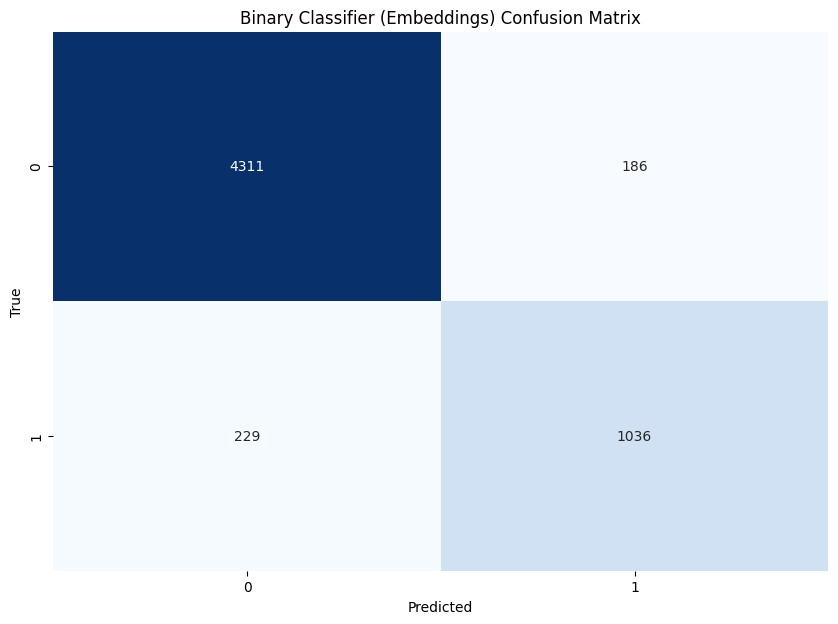

In [25]:
all_preds, all_labels = evaluate_model(classifier_v3, emb_test_dataloader, device)
y_pred = np.argmax(all_preds, axis=1)
plot_confusion_matrix(all_labels, y_pred, title='Binary Classifier (Embeddings) Confusion Matrix')

In [26]:
torch.save(classifier_v3.state_dict(), "../models/EMBClassifier.pth")

#### Feature Importance - Embeddingi

In [28]:
baseline_roc_auc = roc_auc_score(all_labels, all_preds[:, 1])

In [30]:
numeric_columns = emb_numerical_columns

importances = permutation_importance_dataloader_advanced(
    model=classifier_v3,
    dataloader=emb_val_dataloader,
    emb_categorical_columns=emb_categorical_columns,
    numeric_columns=numeric_columns,
    baseline_score=baseline_roc_auc,
    device=device,
    max_group_size=2)

In [31]:
print("\nPermutation Feature Importances (by ROC AUC drop):")
for col, drop in importances:
    print(f"{col}: {drop:.4f}")


Permutation Feature Importances (by ROC AUC drop):
['review_scores_value', 'num_of_top_10_common_amenities']: 0.4296
['host_is_superhost', 'review_scores_value']: 0.4248
['bedrooms', 'review_scores_value']: 0.4027
['longitude', 'review_scores_value']: 0.3960
['review_scores_checkin', 'review_scores_value']: 0.3955
['review_scores_value', 'num_of_amenities']: 0.3954
['review_scores_value', 'count_negative_english']: 0.3950
['bathrooms_text', 'review_scores_value']: 0.3919
['host_acceptance_rate', 'review_scores_value']: 0.3909
['price', 'review_scores_value']: 0.3902
['review_scores_accuracy', 'review_scores_value']: 0.3900
['beds', 'review_scores_value']: 0.3896
['property_type', 'review_scores_value']: 0.3896
['instant_bookable', 'review_scores_value']: 0.3885
['review_scores_cleanliness', 'review_scores_value']: 0.3879
['review_scores_value', 'total_reviews']: 0.3868
['review_scores_rating', 'review_scores_value']: 0.3861
['room_type', 'review_scores_value']: 0.3859
['license', 'rev

In [32]:
importances_singular = permutation_importance_dataloader_advanced(
    model=classifier_v3,
    dataloader=emb_val_dataloader,
    emb_categorical_columns=emb_categorical_columns,
    numeric_columns=numeric_columns,
    baseline_score=baseline_roc_auc,
    device=device,
    max_group_size=1
)

print("\nPermutation Feature Importances (by ROC AUC drop):")
for col, drop in importances_singular:
    print(f"{col}: {drop:.4f}")


Permutation Feature Importances (by ROC AUC drop):
['review_scores_value']: 0.3788
['num_of_top_10_common_amenities']: 0.2510
['host_is_superhost']: 0.2101
['bedrooms']: 0.1981
['bathrooms']: 0.1199
['bathrooms_text']: 0.1044
['property_type']: 0.1035
['review_scores_cleanliness']: 0.1031
['review_scores_rating']: 0.1006
['review_scores_checkin']: 0.1005
['review_scores_communication']: 0.0994
['num_of_amenities']: 0.0970
['review_scores_accuracy']: 0.0970
['count_positive_english']: 0.0965
['latitude']: 0.0965
['total_reviews']: 0.0961
['total_english_reviews']: 0.0959
['license']: 0.0959
['price']: 0.0956
['reviews_per_month']: 0.0956
['room_type']: 0.0954
['count_negative_english']: 0.0954
['num_of_other_amenities']: 0.0950
['neighbourhood_cleansed']: 0.0948
['total_bookings']: 0.0946
['instant_bookable']: 0.0945
['longitude']: 0.0944
['beds']: 0.0944
['review_scores_location']: 0.0944
['accommodates']: 0.0934
['host_verifications']: 0.0932
['host_acceptance_rate']: 0.0932


## 5. XGBoost

In [35]:
xgboost_df = create_ohe_dataset(
    df=final_df,
    drop_cols=DROP_COLUMNS,
    drop_post_ohe=POST_COLUMNS,
    target_col='target',
    fillna_value=0
)

xgboost_df = clean_column_names(xgboost_df)

xgboost_df.head()

,host_acceptance_rate,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,review_scores_rating,review_scores_accuracy,...,bathrooms_text_7 shared baths,bathrooms_text_8 baths,bathrooms_text_8 shared baths,bathrooms_text_8.5 baths,bathrooms_text_9 baths,bathrooms_text_Half-bath,bathrooms_text_Private half-bath,bathrooms_text_Shared half-bath,instant_bookable_f,instant_bookable_t
0,100.0,37.98924,23.76500,2,1.0,1.0,1.0,131.0,4.86,4.89,...,False,False,False,False,False,False,False,False,False,True
1,96.0,37.96215,23.72179,4,1.0,1.0,2.0,108.0,4.96,4.97,...,False,False,False,False,False,False,False,False,True,False
2,97.0,37.95523,23.72443,3,1.0,1.0,1.0,85.0,4.95,4.98,...,False,False,False,False,False,False,False,False,True,False
3,0.0,37.99745,23.73973,2,1.0,1.0,1.0,56.0,4.61,4.88,...,False,False,False,False,False,False,False,False,True,False
4,100.0,37.98844,23.73845,2,1.0,1.0,1.0,63.0,4.95,4.94,...,False,False,False,False,False,False,False,False,False,True


In [37]:
set_seed(42)

PYTHONHASHSEED       → 42
CUBLAS_WORKSPACE_CONFIG → :4096:8
python.random_seed   → 2147483648
numpy.random_seed    → 42
torch.cpu_seed       → 42
torch.cuda_seed      → 42


In [38]:
x_train, x_test, y_train, y_test = train_test_split_data(
    xgboost_df,
    test_size=0.2,
    target_column='target'
)

In [39]:
xgb_classifier = XGBClassifier()
xgb_classifier.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [40]:
y_pred = xgb_classifier.predict(x_test)

y_pred_proba = xgb_classifier.predict_proba(x_test)

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_pred_proba[:, 1]):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9733
ROC AUC: 0.9962
Average Precision: 0.9868

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      4497
           1       0.95      0.93      0.94      1265

    accuracy                           0.97      5762
   macro avg       0.96      0.96      0.96      5762
weighted avg       0.97      0.97      0.97      5762



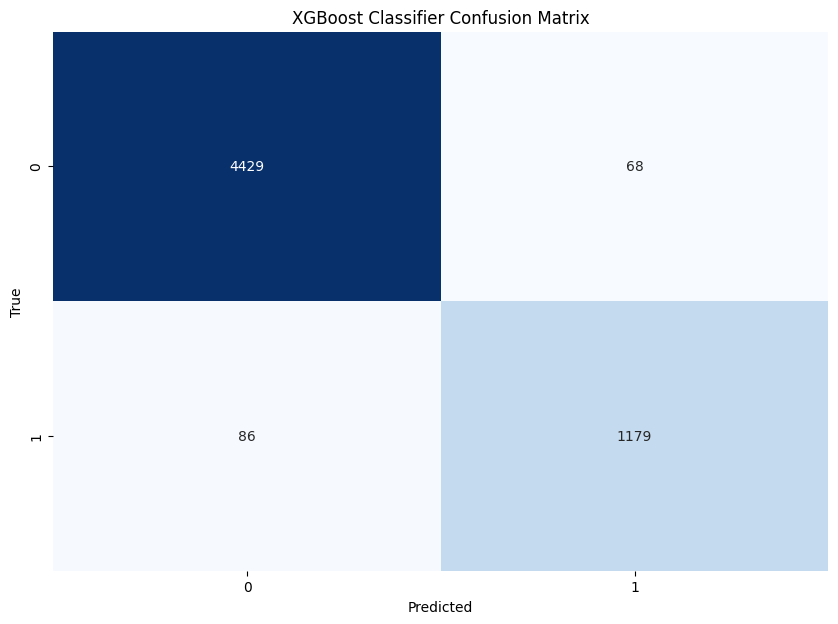

In [41]:
plot_confusion_matrix(y_test, y_pred, title='XGBoost Classifier Confusion Matrix')

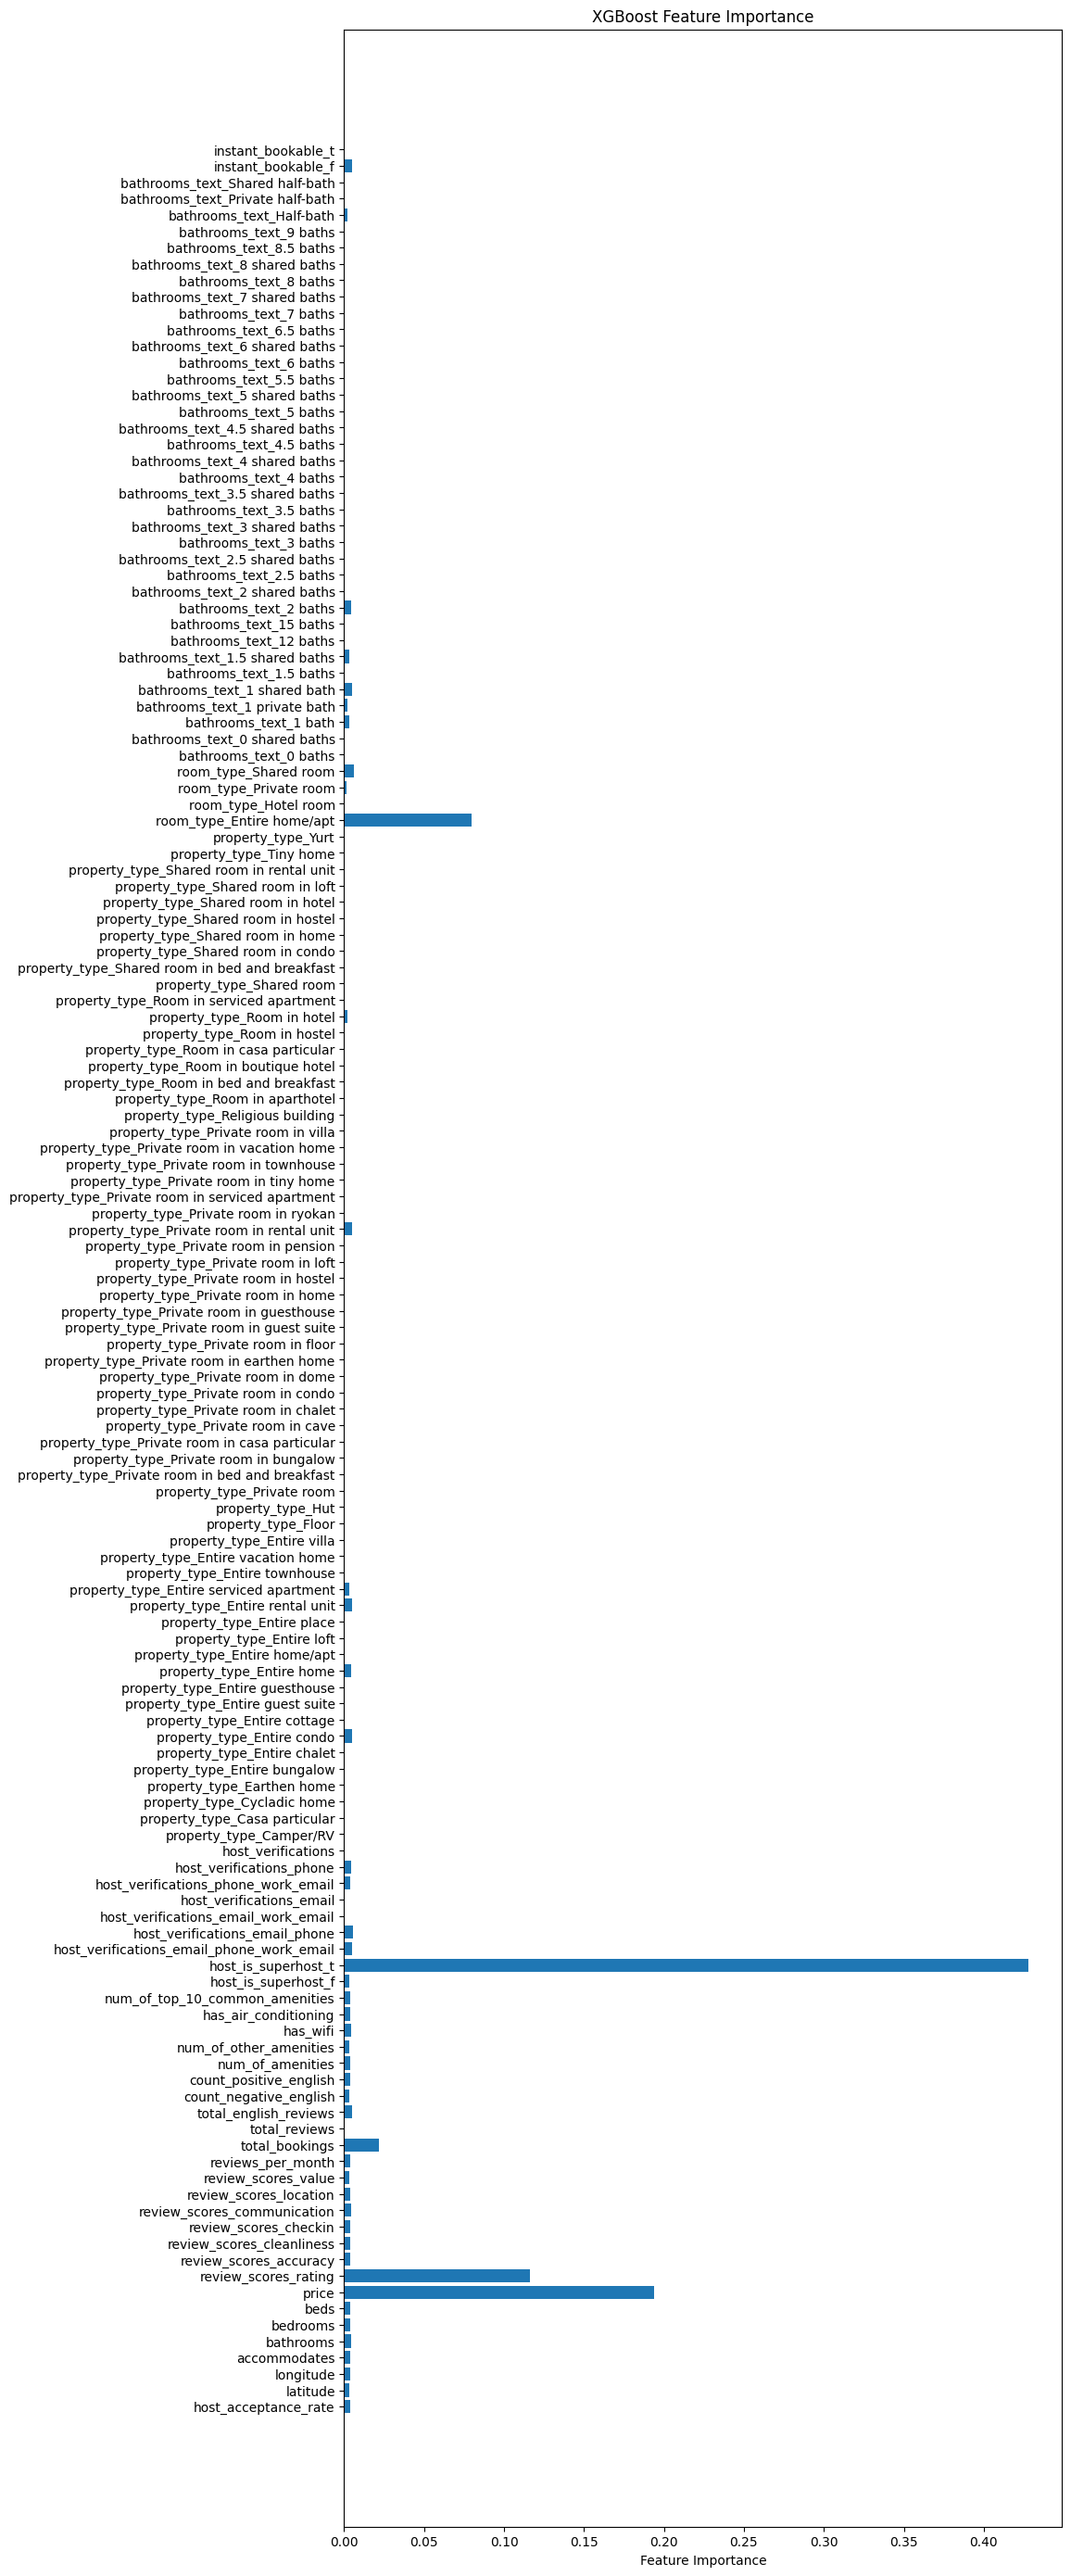

In [42]:
importances = xgb_classifier.feature_importances_

plt.figure(figsize=(10, 35))
plt.barh(x_train.columns, importances)
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importance")
plt.show()

## Wnioski

- **One-Hot Encoding (OHE)**
  - Modele wykorzystujące pełny one-hot encoding kategorii osiągają najwyższe metryki (accuracy, ROC-AUC, average precision).
  - Przewaga nad podejściem embeddingowym jest widoczna, lecz relatywnie niewielka — embeddingi również radzą sobie solidnie.

- **XGBoost**
  - Najlepsze rezultaty daje XGBoost, zarówno na danych OHE, jak i embeddingowych.
  - Przewyższa proste modele drzewiaste i liniowe pod względem stabilności oraz skuteczności.

- **Model naiwny**
  - Wyniki prostego klasyfikatora bazowego (np. reguła “zawsze krótki pobyt”) pokrywają się z założeniami i obserwacjami z raportu wstępnego.
  - Stanowi solidny punkt odniesienia dla bardziej zaawansowanych metod.
  
<br>

---

## Kolejne kroki

W celu dalszej poprawy wydajności skoncentrujemy się na **optymalizacji hiperparametrów** dla dwóch wiodących podejść:

1. **XGBoost**  
2. **Model z warstwami embeddingów**

Dzięki temu unikniemy duplikowania prac nad modelem OHE, a jednocześnie wydobędziemy maksimum z najbardziej obiecujących architektur.